# Redes neurais convolucionais para classificação de imagens

## Importação de Bibliotecas

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy

## Carregamento de Imagens

In [10]:
path = r'datasets\homer_bart_2.zip'

In [11]:
zip_object = zipfile.ZipFile(file = path, mode = 'r')
zip_object.extractall('./')
zip_object.close()

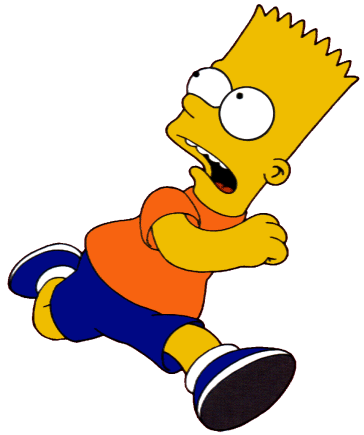

In [2]:
tf.keras.preprocessing.image.load_img('homer_bart_2/training_set/bart/bart100.bmp')

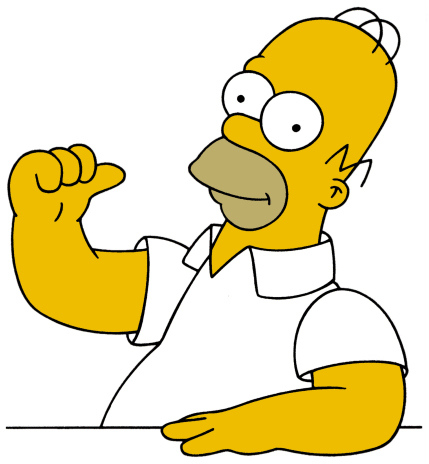

In [3]:
tf.keras.preprocessing.image.load_img('homer_bart_2/training_set/homer/homer102.bmp')

## Bases de treinamento e teste

In [28]:
gerador_treinamento = ImageDataGenerator(rescale=1./255,
                                         rotation_range=7,
                                         horizontal_flip=True,
                                         zoom_range=0.2)

In [29]:
dataset_treinamento = gerador_treinamento.flow_from_directory(r'homer_bart_2\training_set',
                                                              target_size = (64, 64),
                                                              batch_size = 8,
                                                              class_mode = 'categorical',
                                                              shuffle = True)

Found 215 images belonging to 2 classes.


In [30]:
dataset_treinamento.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [31]:
dataset_treinamento.class_indices

{'bart': 0, 'homer': 1}

In [32]:
gerador_teste = ImageDataGenerator(rescale=1./255)
dataset_teste = gerador_teste.flow_from_directory(r'homer_bart_2\test_set',
                                                  target_size = (64,64),
                                                  batch_size = 1,
                                                  class_mode = 'categorical',
                                                  shuffle=False)

Found 54 images belonging to 2 classes.


## Construção e treinamento de rede neural

In [33]:
6 * 6 * 32

1152

In [34]:
(1152 + 2)/ 2

577.0

In [35]:
network = Sequential()
network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(64,64,3)))
network.add(MaxPool2D(pool_size=(2,2)))

network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
network.add(MaxPool2D(pool_size=(2,2)))

network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
network.add(MaxPool2D(pool_size=(2,2)))

network.add(Flatten())

network.add(Dense(units=577, activation='relu'))
network.add(Dense(units=577, activation='relu'))
network.add(Dense(units=2, activation='softmax'))

c:\Users\milcastro\OneDrive - Deloitte (O365D)\Imagens\Programacao\cv-studies\5-cnn-para-classificacao-de-imagens\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
network.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 577)            │       665,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 577)            │       333,506 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,019,335 (3.89 MB)

 Trainable params: 1,019,335 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
network.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [38]:
historico = network.fit(dataset_treinamento, epochs=50)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.5953 - loss: 0.7023
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6233 - loss: 0.6467
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6837 - loss: 0.5709
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7581 - loss: 0.4559
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8000 - loss: 0.4312
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8186 - loss: 0.3785
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8465 - loss: 0.3415
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8372 - loss: 0.3470
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8465 - loss: 0.3343
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8791 - loss: 0.2777
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9023 - loss: 0.2385
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy

## Avaliação da rede neural

In [39]:
dataset_teste.class_indices

{'bart': 0, 'homer': 1}

In [40]:
previsoes = network.predict(dataset_teste)
previsoes

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


array([[1.0000000e+00, 3.9860601e-18],
       [1.0000000e+00, 1.0013504e-13],
       [6.6546301e-05, 9.9993348e-01],
       [9.9999988e-01, 1.0316392e-07],
       [1.0000000e+00, 3.5446137e-14],
       [1.0000000e+00, 3.2821623e-09],
       [9.9796695e-01, 2.0330295e-03],
       [9.9161738e-01, 8.3826287e-03],
       [8.1334209e-01, 1.8665791e-01],
       [9.9991548e-01, 8.4508145e-05],
       [9.9997783e-01, 2.2227588e-05],
       [9.9999952e-01, 5.2390146e-07],
       [9.9991381e-01, 8.6147149e-05],
       [1.0000000e+00, 5.1611369e-08],
       [9.9147850e-01, 8.5214563e-03],
       [1.0000000e+00, 6.0410767e-11],
       [9.9707687e-01, 2.9231317e-03],
       [9.9999666e-01, 3.2938399e-06],
       [9.9992669e-01, 7.3267205e-05],
       [1.0000000e+00, 8.6576276e-13],
       [9.9997234e-01, 2.7686438e-05],
       [1.0000000e+00, 1.2403689e-14],
       [1.0000000e+00, 1.5535283e-08],
       [4.8890927e-01, 5.1109070e-01],
       [9.9999988e-01, 1.1217642e-07],
       [9.9999976e-01, 1.

In [41]:
previsoes = np.argmax(previsoes, axis=1)
previsoes

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

In [42]:
dataset_teste.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

accuracy_score(dataset_teste.classes, previsoes)

0.8888888888888888

<Axes: >

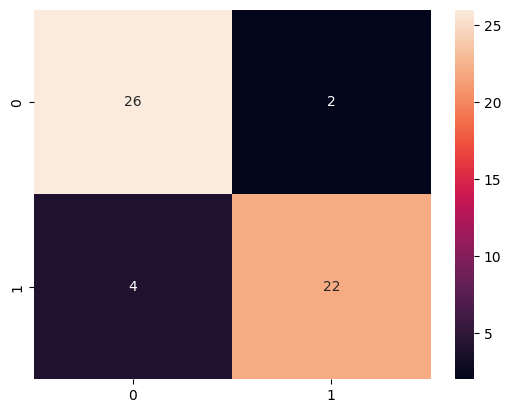

In [50]:
cm = confusion_matrix(dataset_teste.classes, previsoes) 
sns.heatmap(cm, annot=True)

In [51]:
print(classification_report(dataset_teste.classes, previsoes, target_names=['bart', 'homer']))

              precision    recall  f1-score   support

        bart       0.87      0.93      0.90        28
       homer       0.92      0.85      0.88        26

    accuracy                           0.89        54
   macro avg       0.89      0.89      0.89        54
weighted avg       0.89      0.89      0.89        54



## Salvando e Carregando rede neural

In [56]:
model_json = network.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

In [57]:
from keras.models import save_model
network_saved = save_model(network, 'models\cnn_homer_bart2.hdf5')

In [58]:
with open('models\model.json', 'r') as json_file:
    json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_1", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 64, 64, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer_1"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Conv2D", "config": {"name": "conv2d_3", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "valid", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"mo

In [59]:
network_loaded = tf.keras.models.model_from_json(json_saved_model)
network_loaded.load_weights('models\cnn_homer_bart2.hdf5')
network_loaded.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
network_loaded.summary()